✅ Dataset loaded! Shape: (25000, 53)

✅ Features being used (25):
['delivery_partner', 'package_type', 'vehicle_type', 'delivery_mode', 'region', 'weather_condition', 'distance_km', 'package_weight_kg', 'delivery_cost', 'expected_time_hours_recon', 'order_dayofweek', 'order_day_name', 'order_month', 'order_year', 'order_hour', 'is_weekend', 'rush_hour_flag', 'night_delivery_flag', 'cost_per_km', 'cost_per_kg', 'heavy_flag', 'bad_weather_flag', 'weather_severity', 'weather_distance_risk', 'load_index']

🎯 Target distribution:
target
0    18331
1     6669
Name: count, dtype: int64
Delay rate: 26.68% (using original delayed column)

📝 Encoding: ['delivery_partner', 'package_type', 'vehicle_type', 'delivery_mode', 'region', 'weather_condition', 'order_day_name']
✅ Encoding done!

✅ Split done!
   Training: 20000 samples
   Testing:  5000 samples

✅ Delay rate features added (computed on train only — no leakage)

✅ Features scaled!

🌲 Training Random Forest...
✅ Random Forest done!

📈 Train

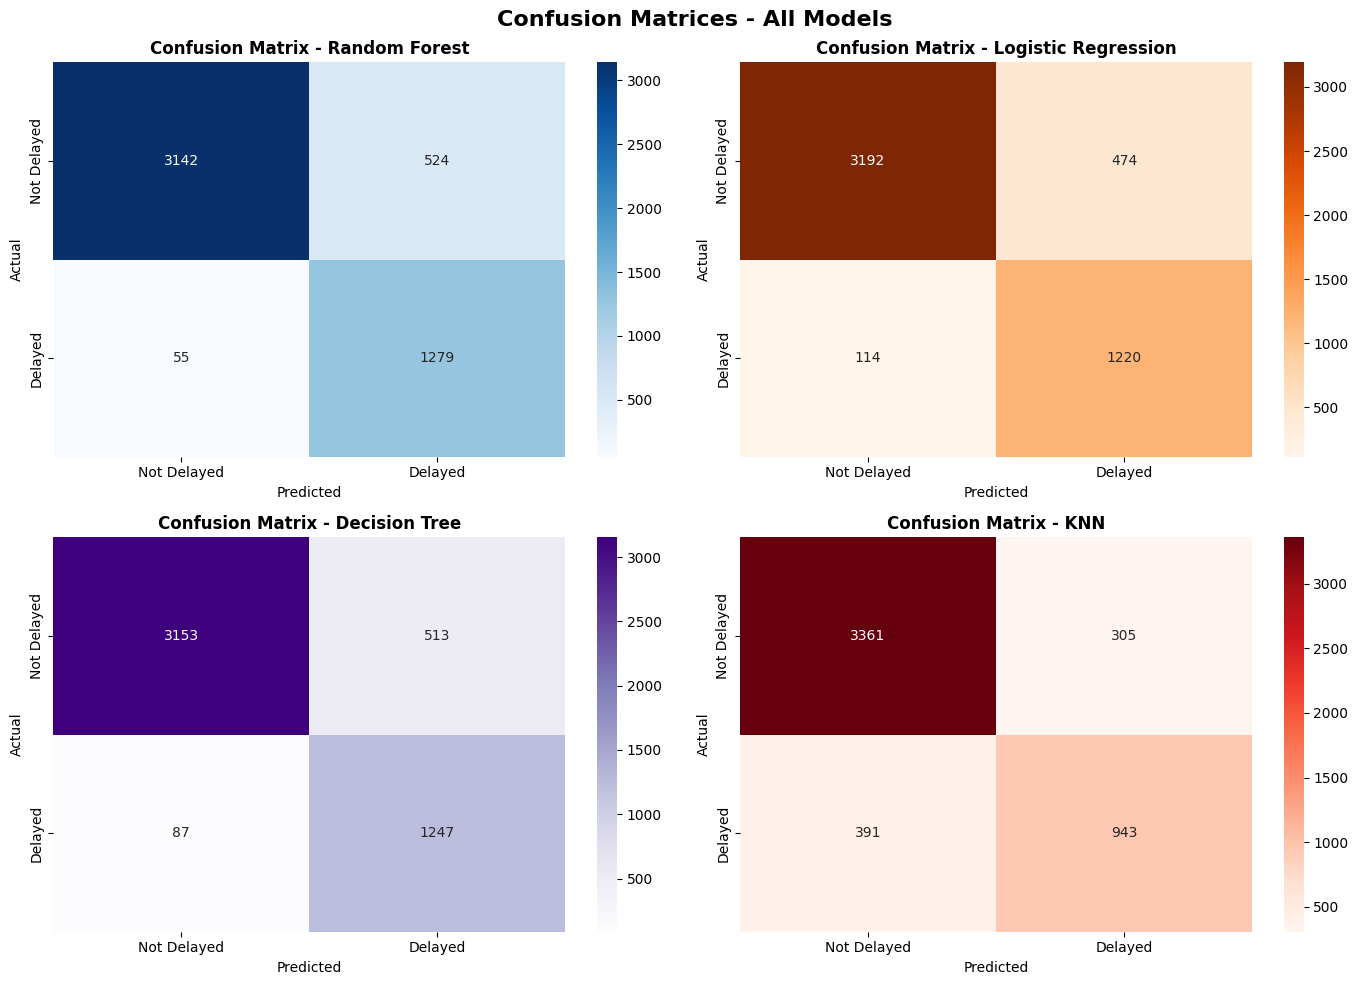

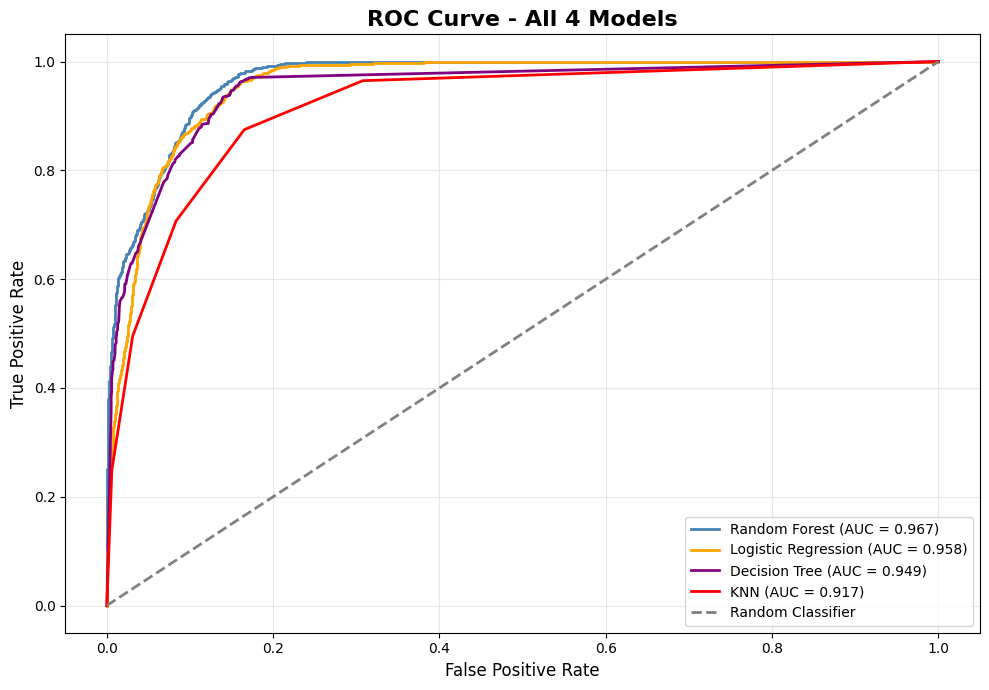

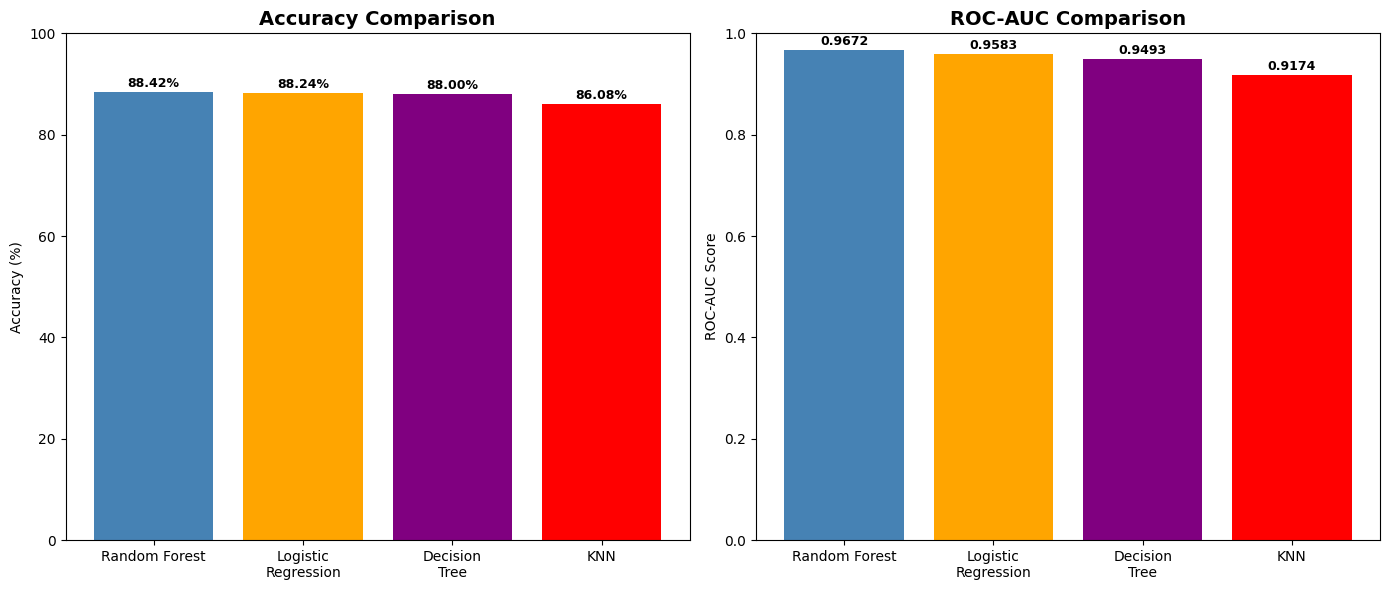

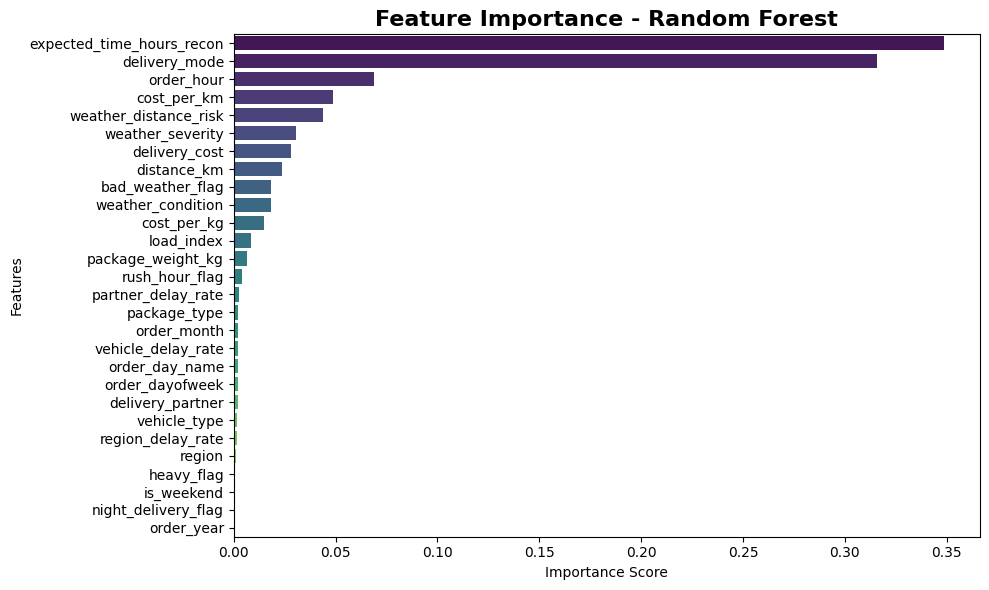


🏆 FINAL MODEL COMPARISON - ALL 4 MODELS
              Model Accuracy (%) ROC-AUC PR-AUC
      Random Forest        88.42  0.9672 0.9131
Logistic Regression        88.24  0.9583 0.8743
      Decision Tree        88.00  0.9493 0.8715
                KNN        86.08  0.9174 0.7714

🥇 Best by Accuracy: Random Forest (88.42%)
🥇 Best by ROC-AUC:  Random Forest (0.9672)

✅ All 4 models saved!
   - rf_delivery_model.pkl
   - lr_delivery_model.pkl
   - dt_delivery_model.pkl
   - knn_delivery_model.pkl
   - scaler.pkl
   - label_encoders.pkl


In [ ]:
# ============================================================
# IMPORTS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, roc_auc_score, roc_curve,
                              average_precision_score, precision_recall_curve,
                              f1_score, precision_score, recall_score)

# ============================================================
# STEP 1: LOAD DATA
# ============================================================
df = pd.read_csv("eta_feature_engineered_dataset.csv")
print(f"✅ Dataset loaded! Shape: {df.shape}")

# ============================================================
# STEP 2: SELECT SAFE FEATURES (No Data Leakage)
# ============================================================
# Only use features that would be KNOWN at the time of order placement.
# Dropped: actual delivery times, delay hours, severity, efficiency,
#          time_ratio, early_flag — all derived from the outcome.
# FIX: Removed speed_category — actual travel speed is only known AFTER delivery.
# NOTE: partner/region/vehicle delay rates are NOT included here — they will be
#       computed on TRAIN only after the split to prevent leakage (Step 4b).

SAFE_FEATURES = [
    'delivery_partner', 'package_type', 'vehicle_type', 'delivery_mode',
    'region', 'weather_condition', 'distance_km', 'package_weight_kg',
    'delivery_cost', 'expected_time_hours_recon', 'order_dayofweek',
    'order_day_name', 'order_month', 'order_year', 'order_hour',
    'is_weekend', 'rush_hour_flag', 'night_delivery_flag',
    'cost_per_km', 'cost_per_kg', 'heavy_flag', 'bad_weather_flag',
    'weather_severity', 'weather_distance_risk', 'load_index',
]

# Filter to columns that exist in dataset
SAFE_FEATURES = [f for f in SAFE_FEATURES if f in df.columns]

X = df[SAFE_FEATURES].copy()
# Convert original 'delayed' yes/no to binary 0/1
df['target'] = (df['delayed'] == 'yes').astype(int)
y = df['target']

print(f"\n✅ Features being used ({len(X.columns)}):")
print(X.columns.tolist())
print(f"\n🎯 Target distribution:")
print(y.value_counts())
print(f"Delay rate: {y.mean()*100:.2f}% (using original delayed column)")

# ============================================================
# STEP 3: ENCODE CATEGORICAL VARIABLES
# ============================================================
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
print(f"\n📝 Encoding: {categorical_cols}")

label_encoders = {}
X_encoded = X.copy()

for col in categorical_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))
    label_encoders[col] = le

print("✅ Encoding done!")

# ============================================================
# STEP 4: TRAIN-TEST SPLIT (80-20)
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\n✅ Split done!")
print(f"   Training: {X_train.shape[0]} samples")
print(f"   Testing:  {X_test.shape[0]} samples")

# ============================================================
# STEP 4b: DELAY RATE FEATURES — COMPUTED ON TRAIN ONLY
# ============================================================
# FIX: Previously these were computed on the full dataset before the split
# (feature engineering cells 75-77), causing data leakage — test-set outcomes
# were influencing training features.
# Fix: recompute from training rows only, then map to test.
# ============================================================
global_rate = y_train.mean()

for orig_col, rate_col in [
    ('delivery_partner', 'partner_delay_rate'),
    ('region',           'region_delay_rate'),
    ('vehicle_type',     'vehicle_delay_rate'),
]:
    rate_map = df.loc[y_train.index].groupby(orig_col)['target'].mean()
    X_train[rate_col] = df.loc[y_train.index, orig_col].map(rate_map).fillna(global_rate).values
    X_test[rate_col]  = df.loc[y_test.index,  orig_col].map(rate_map).fillna(global_rate).values

print(f"\n✅ Delay rate features added (computed on train only — no leakage)")

# ============================================================
# STEP 5: SCALE FEATURES
# ============================================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print("\n✅ Features scaled!")

# ============================================================
# STEP 6: TRAIN ALL 4 MODELS
# ============================================================

# 1. Random Forest
print("\n🌲 Training Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)
rf_model.fit(X_train_scaled, y_train)
print("✅ Random Forest done!")

# 2. Logistic Regression
print("\n📈 Training Logistic Regression...")
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    C=1.0,
    class_weight='balanced'
)
lr_model.fit(X_train_scaled, y_train)
print("✅ Logistic Regression done!")

# 3. Decision Tree
print("\n🌳 Training Decision Tree...")
dt_model = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    class_weight='balanced'
)
dt_model.fit(X_train_scaled, y_train)
print("✅ Decision Tree done!")

# 4. KNN
print("\n👥 Training KNN...")
knn_model = KNeighborsClassifier(
    n_neighbors=5,
    metric='euclidean'
)
knn_model.fit(X_train_scaled, y_train)
print("✅ KNN done!")

# ============================================================
# STEP 7: PREDICTIONS - ALL 4 MODELS
# ============================================================
y_pred_rf  = rf_model.predict(X_test_scaled)
y_pred_lr  = lr_model.predict(X_test_scaled)
y_pred_dt  = dt_model.predict(X_test_scaled)
y_pred_knn = knn_model.predict(X_test_scaled)

y_proba_rf  = rf_model.predict_proba(X_test_scaled)[:, 1]
y_proba_lr  = lr_model.predict_proba(X_test_scaled)[:, 1]
y_proba_dt  = dt_model.predict_proba(X_test_scaled)[:, 1]
y_proba_knn = knn_model.predict_proba(X_test_scaled)[:, 1]

print("\n✅ All predictions done!")

# ============================================================
# STEP 8: EVALUATE ALL 4 MODELS
# ============================================================
rf_acc  = accuracy_score(y_test, y_pred_rf)
lr_acc  = accuracy_score(y_test, y_pred_lr)
dt_acc  = accuracy_score(y_test, y_pred_dt)
knn_acc = accuracy_score(y_test, y_pred_knn)

rf_auc  = roc_auc_score(y_test, y_proba_rf)
lr_auc  = roc_auc_score(y_test, y_proba_lr)
dt_auc  = roc_auc_score(y_test, y_proba_dt)
knn_auc = roc_auc_score(y_test, y_proba_knn)

# PR-AUC (most honest metric for imbalanced data)
rf_prauc  = average_precision_score(y_test, y_proba_rf)
lr_prauc  = average_precision_score(y_test, y_proba_lr)
dt_prauc  = average_precision_score(y_test, y_proba_dt)
knn_prauc = average_precision_score(y_test, y_proba_knn)

print("\n" + "="*60)
print("🌲 RANDOM FOREST")
print("="*60)
print(f"Accuracy: {rf_acc*100:.2f}% | ROC-AUC: {rf_auc:.4f} | PR-AUC: {rf_prauc:.4f}")
print(classification_report(y_test, y_pred_rf, target_names=['Not Delayed', 'Delayed']))

print("="*60)
print("📈 LOGISTIC REGRESSION")
print("="*60)
print(f"Accuracy: {lr_acc*100:.2f}% | ROC-AUC: {lr_auc:.4f} | PR-AUC: {lr_prauc:.4f}")
print(classification_report(y_test, y_pred_lr, target_names=['Not Delayed', 'Delayed']))

print("="*60)
print("🌳 DECISION TREE")
print("="*60)
print(f"Accuracy: {dt_acc*100:.2f}% | ROC-AUC: {dt_auc:.4f} | PR-AUC: {dt_prauc:.4f}")
print(classification_report(y_test, y_pred_dt, target_names=['Not Delayed', 'Delayed']))

print("="*60)
print("👥 KNN")
print("="*60)
print(f"Accuracy: {knn_acc*100:.2f}% | ROC-AUC: {knn_auc:.4f} | PR-AUC: {knn_prauc:.4f}")
print(classification_report(y_test, y_pred_knn, target_names=['Not Delayed', 'Delayed']))

# ============================================================
# STEP 9: CONFUSION MATRICES - ALL 4
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

models_info = [
    (y_pred_rf,  'Random Forest',       'Blues'),
    (y_pred_lr,  'Logistic Regression', 'Oranges'),
    (y_pred_dt,  'Decision Tree',       'Purples'),
    (y_pred_knn, 'KNN',                 'Reds'),
]

for i, (y_pred, title, cmap) in enumerate(models_info):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=axes[i],
                xticklabels=['Not Delayed', 'Delayed'],
                yticklabels=['Not Delayed', 'Delayed'])
    axes[i].set_title(f'Confusion Matrix - {title}', fontweight='bold')
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')

plt.suptitle('Confusion Matrices - All Models', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================
# STEP 10: ROC CURVE - ALL 4 MODELS
# ============================================================
fpr_rf,  tpr_rf,  _ = roc_curve(y_test, y_proba_rf)
fpr_lr,  tpr_lr,  _ = roc_curve(y_test, y_proba_lr)
fpr_dt,  tpr_dt,  _ = roc_curve(y_test, y_proba_dt)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_proba_knn)

plt.figure(figsize=(10, 7))
plt.plot(fpr_rf,  tpr_rf,  color='steelblue', lw=2, label=f'Random Forest (AUC = {rf_auc:.3f})')
plt.plot(fpr_lr,  tpr_lr,  color='orange',    lw=2, label=f'Logistic Regression (AUC = {lr_auc:.3f})')
plt.plot(fpr_dt,  tpr_dt,  color='purple',    lw=2, label=f'Decision Tree (AUC = {dt_auc:.3f})')
plt.plot(fpr_knn, tpr_knn, color='red',       lw=2, label=f'KNN (AUC = {knn_auc:.3f})')
plt.plot([0, 1],  [0, 1],  color='gray', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - All 4 Models', fontsize=16, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# STEP 11: COMPARISON BAR CHART
# ============================================================
all_models     = ['Random Forest', 'Logistic\nRegression', 'Decision\nTree', 'KNN']
all_accuracies = [rf_acc*100, lr_acc*100, dt_acc*100, knn_acc*100]
all_roc_aucs   = [rf_auc, lr_auc, dt_auc, knn_auc]
all_colors     = ['steelblue', 'orange', 'purple', 'red']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].bar(all_models, all_accuracies, color=all_colors)
axes[0].set_title('Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim([0, 100])
for i, v in enumerate(all_accuracies):
    axes[0].text(i, v + 1, f'{v:.2f}%', ha='center', fontweight='bold', fontsize=9)

axes[1].bar(all_models, all_roc_aucs, color=all_colors)
axes[1].set_title('ROC-AUC Comparison', fontsize=14, fontweight='bold')
axes[1].set_ylabel('ROC-AUC Score')
axes[1].set_ylim([0, 1])
for i, v in enumerate(all_roc_aucs):
    axes[1].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

# ============================================================
# STEP 12: FEATURE IMPORTANCE (RANDOM FOREST)
# ============================================================
feature_importance = pd.DataFrame({
    'feature': list(X_train.columns),
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='importance', y='feature', palette='viridis')
plt.title('Feature Importance - Random Forest', fontsize=16, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# ============================================================
# STEP 13: SUMMARY TABLE
# ============================================================
summary = pd.DataFrame({
    'Model':        ['Random Forest', 'Logistic Regression', 'Decision Tree', 'KNN'],
    'Accuracy (%)': [f"{v:.2f}" for v in all_accuracies],
    'ROC-AUC':      [f"{v:.4f}" for v in all_roc_aucs],
    'PR-AUC':       [f"{v:.4f}" for v in [rf_prauc, lr_prauc, dt_prauc, knn_prauc]]
})

print("\n🏆 FINAL MODEL COMPARISON - ALL 4 MODELS")
print("="*50)
print(summary.to_string(index=False))

best_acc_idx = all_accuracies.index(max(all_accuracies))
best_auc_idx = all_roc_aucs.index(max(all_roc_aucs))
print(f"\n🥇 Best by Accuracy: {summary['Model'][best_acc_idx]} ({max(all_accuracies):.2f}%)")
print(f"🥇 Best by ROC-AUC:  {summary['Model'][best_auc_idx]} ({max(all_roc_aucs):.4f})")

# ============================================================
# STEP 14: SAVE ALL MODELS
# ============================================================
with open('rf_delivery_model.pkl',  'wb') as f: pickle.dump(rf_model,       f)
with open('lr_delivery_model.pkl',  'wb') as f: pickle.dump(lr_model,       f)
with open('dt_delivery_model.pkl',  'wb') as f: pickle.dump(dt_model,       f)
with open('knn_delivery_model.pkl', 'wb') as f: pickle.dump(knn_model,      f)
with open('scaler.pkl',             'wb') as f: pickle.dump(scaler,         f)
with open('label_encoders.pkl',     'wb') as f: pickle.dump(label_encoders, f)

print("\n✅ All 4 models saved!")
print("   - rf_delivery_model.pkl")
print("   - lr_delivery_model.pkl")
print("   - dt_delivery_model.pkl")
print("   - knn_delivery_model.pkl")
print("   - scaler.pkl")
print("   - label_encoders.pkl")
